# 05.5 — Dataset Review

Where we are, what the data looks like, and whether we have enough to train.

**Current dataset:** `data/processed/train.jsonl` + `eval.jsonl`

In [2]:
import sys, json, random
sys.path.insert(0, '..')
from pathlib import Path
from collections import Counter
from IPython.display import Image, display, HTML
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

with open('../data/processed/train.jsonl') as f:
    train = [json.loads(l) for l in f]
with open('../data/processed/eval.jsonl') as f:
    evl = [json.loads(l) for l in f]
all_examples = train + evl

print(f'Train: {len(train)}  |  Eval: {len(evl)}  |  Total: {len(all_examples)}')

Train: 3150  |  Eval: 350  |  Total: 3500


## Dataset at a glance

In [3]:
# Aggregate metadata
schema_types = Counter()
tlds = Counter()
quality_scores = []
html_lens = []
has_screenshot = 0
jsonld_lens = []
props = Counter()

for ex in all_examples:
    meta = ex['metadata']
    for t in meta.get('schema_types', ['Unknown']):
        schema_types[t] += 1
    tld = meta['domain'].split('.')[-1] if meta['domain'] else 'unknown'
    tlds[tld] += 1
    quality_scores.append(meta['quality_score'])
    user = ex['messages'][1]['content']
    html_text = next((c['text'] for c in user if c['type'] == 'text'), '')
    html_lens.append(len(html_text))
    if any(c['type'] == 'image' for c in user):
        has_screenshot += 1
    assistant = ex['messages'][2]['content']
    jsonld_lens.append(len(assistant))
    try:
        for k in json.loads(assistant): props[k] += 1
    except: pass

print(f"Schema types:    {dict(schema_types.most_common())}")
print(f"With screenshot: {has_screenshot}/{len(all_examples)} ({100*has_screenshot/len(all_examples):.0f}%)")
print(f"Quality score:   mean={np.mean(quality_scores):.2f}  min={min(quality_scores):.2f}  max={max(quality_scores):.2f}")
print(f"HTML length:     mean={np.mean(html_lens):,.0f}  median={np.median(html_lens):,.0f}")
print(f"JSON-LD length:  mean={np.mean(jsonld_lens):,.0f}  median={np.median(jsonld_lens):,.0f}")
print(f"Unique domains:  {len(set(ex['metadata']['domain'] for ex in all_examples))}")

Schema types:    {'LocalBusiness': 2442, 'Product': 1058}
With screenshot: 3500/3500 (100%)
Quality score:   mean=0.73  min=0.30  max=1.00
HTML length:     mean=29,890  median=32,080
JSON-LD length:  mean=897  median=758
Unique domains:  1146


## Charts

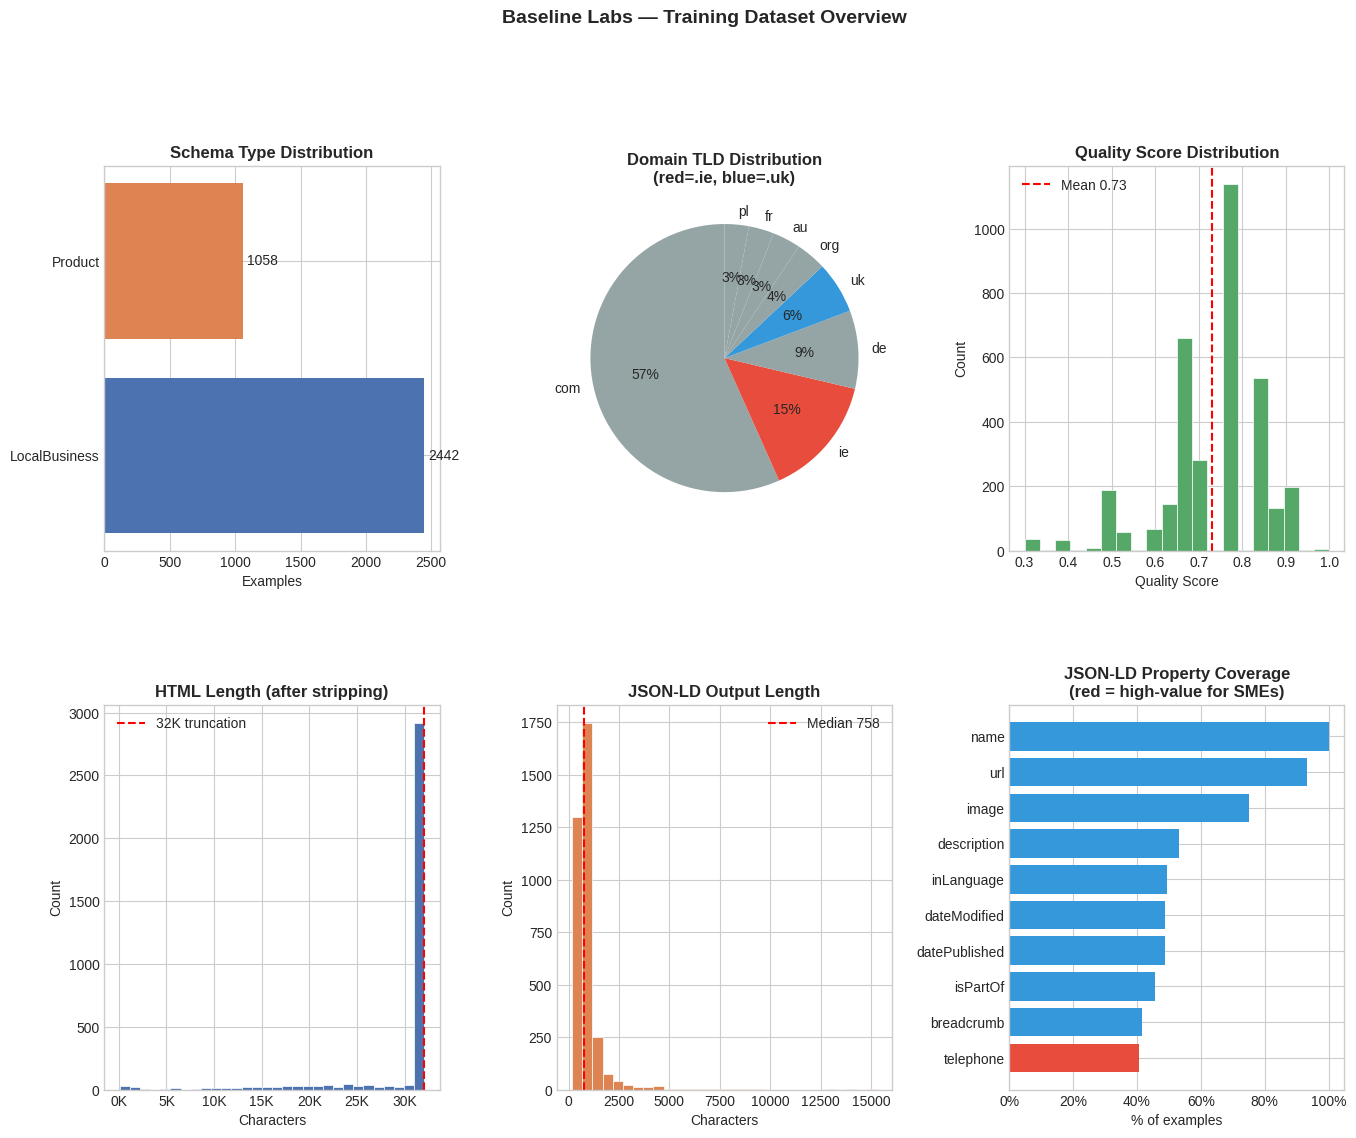

Saved to data/processed/dataset_overview.png


In [4]:
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1 — Schema type distribution
ax1 = fig.add_subplot(gs[0, 0])
types, counts = zip(*schema_types.most_common())
bars = ax1.barh(types, counts, color=['#4C72B0', '#DD8452', '#55A868', '#C44E52'][:len(types)])
ax1.bar_label(bars, padding=3)
ax1.set_title('Schema Type Distribution', fontweight='bold')
ax1.set_xlabel('Examples')

# 2 — TLD distribution (top 8)
ax2 = fig.add_subplot(gs[0, 1])
top_tlds = tlds.most_common(8)
tlabels, tcounts = zip(*top_tlds)
wedge_colors = ['#e74c3c' if t == 'ie' else '#3498db' if t == 'uk' else '#95a5a6' for t in tlabels]
wedges, texts, autotexts = ax2.pie(tcounts, labels=tlabels, autopct='%1.0f%%',
                                    colors=wedge_colors, startangle=90)
ax2.set_title('Domain TLD Distribution\n(red=.ie, blue=.uk)', fontweight='bold')

# 3 — Quality score histogram
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(quality_scores, bins=20, color='#55A868', edgecolor='white', linewidth=0.5)
ax3.axvline(np.mean(quality_scores), color='red', linestyle='--', label=f'Mean {np.mean(quality_scores):.2f}')
ax3.set_title('Quality Score Distribution', fontweight='bold')
ax3.set_xlabel('Quality Score')
ax3.set_ylabel('Count')
ax3.legend()

# 4 — HTML length distribution
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(html_lens, bins=30, color='#4C72B0', edgecolor='white', linewidth=0.5)
ax4.axvline(32000, color='red', linestyle='--', label='32K truncation')
ax4.set_title('HTML Length (after stripping)', fontweight='bold')
ax4.set_xlabel('Characters')
ax4.set_ylabel('Count')
ax4.legend()
ax4.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# 5 — JSON-LD output length
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(jsonld_lens, bins=30, color='#DD8452', edgecolor='white', linewidth=0.5)
ax5.axvline(np.median(jsonld_lens), color='red', linestyle='--', label=f'Median {np.median(jsonld_lens):.0f}')
ax5.set_title('JSON-LD Output Length', fontweight='bold')
ax5.set_xlabel('Characters')
ax5.set_ylabel('Count')
ax5.legend()

# 6 — Top JSON-LD properties
ax6 = fig.add_subplot(gs[1, 2])
top_props = [(k, v) for k, v in props.most_common(12) if k not in ('@context', '@type')]
pnames, pcounts = zip(*top_props)
pct = [100*c/len(all_examples) for c in pcounts]
color_map = ['#e74c3c' if p in ('telephone','address','openingHours','priceRange') else '#3498db' for p in pnames]
bars6 = ax6.barh(pnames[::-1], pct[::-1], color=color_map[::-1])
ax6.set_title('JSON-LD Property Coverage\n(red = high-value for SMEs)', fontweight='bold')
ax6.set_xlabel('% of examples')
ax6.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))

plt.suptitle('Baseline Labs — Training Dataset Overview', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('../data/processed/dataset_overview.png', bbox_inches='tight', dpi=150)
plt.show()
print('Saved to data/processed/dataset_overview.png')

## Random Example Viewer
Run this cell multiple times to browse different examples.

In [ ]:
PROJECT_ROOT = Path('..')   # notebook lives in notebooks/, data is at ../data/

ex = random.choice(train)
meta = ex['metadata']
user = ex['messages'][1]['content']
html_text = next((c['text'] for c in user if c['type'] == 'text'), '')
img_path   = next((c['image'] for c in user if c['type'] == 'image'), None)
jsonld_str = ex['messages'][2]['content']

# Resolve relative screenshot path from notebook directory
full_img_path = (PROJECT_ROOT / img_path) if img_path else None

display(HTML(f"""
<div style='font-family:monospace; background:#f8f9fa; padding:12px; border-radius:6px; margin-bottom:8px'>
  <b>Domain:</b> {meta['domain']} &nbsp;&nbsp;
  <b>Type:</b> {', '.join(meta['schema_types'])} &nbsp;&nbsp;
  <b>Quality:</b> {meta['quality_score']:.2f} &nbsp;&nbsp;
  <b>HTML chars:</b> {len(html_text):,} &nbsp;&nbsp;
  <b>JSON-LD chars:</b> {len(jsonld_str):,}
</div>
"""))

if full_img_path and full_img_path.exists():
    display(HTML('<b>Screenshot:</b>'))
    display(Image(str(full_img_path), width=600))
else:
    display(HTML(f'<i>(screenshot not found: {full_img_path})</i>'))

display(HTML('<br><b>JSON-LD (ground truth label):</b>'))
try:
    pretty = json.dumps(json.loads(jsonld_str), indent=2, ensure_ascii=False)
except:
    pretty = jsonld_str
display(HTML(f"<pre style='background:#272822;color:#f8f8f2;padding:12px;border-radius:6px;overflow:auto'>{pretty}</pre>"))

display(HTML('<br><b>HTML input (first 1500 chars after stripping):</b>'))
display(HTML(f"<pre style='background:#f0f0f0;padding:12px;border-radius:6px;overflow:auto;max-height:300px'>{html_text[len('Generate schema.org JSON-LD for this web page.\n\nHTML:\n'):1500]}</pre>"))

## Do we have enough data?

### The short answer: probably yes for v1, definitely not for production.

**Why 3,150 is workable:**

Qwen3-VL-8B already knows schema.org inside-out from pretraining — it's seen millions of web pages with JSON-LD. What fine-tuning teaches it is *Irish SME patterns specifically*:
- Eircode postal format (`D01 AB23`)
- `+353` telephone prefix  
- `addressCountry: IE`
- Common Irish business naming conventions
- Visual layout patterns of Irish SME sites

For this kind of **domain adaptation** (not teaching a new skill, just specialising an existing one), QLoRA converges in a few hundred steps. 3K examples covers ~1,150 unique domains across LocalBusiness + Product — that's a solid signal.

**Where it'll struggle without more data:**

- Less common schema types (Restaurant, Hotel, Event — we have zero examples of these)
- Overfitting risk: with 3K examples, monitor eval loss carefully

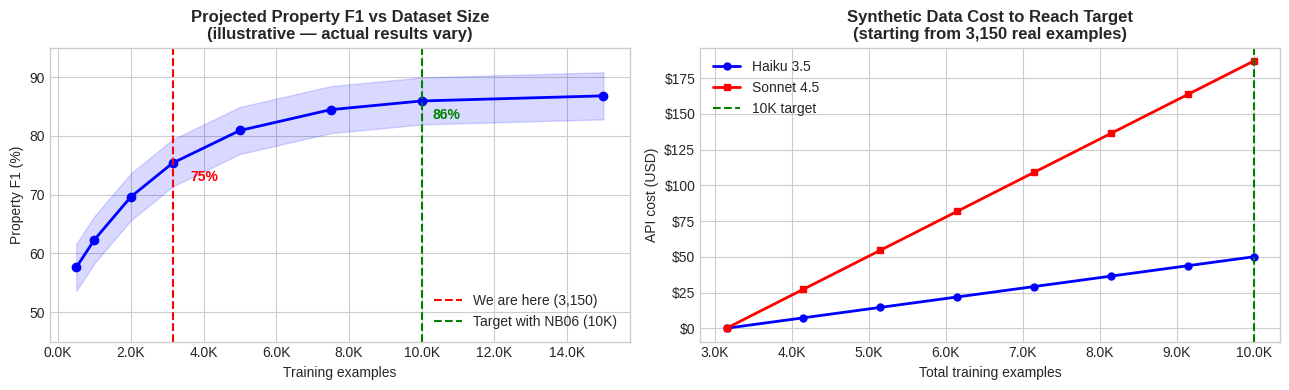

At 3,150 examples → projected ~75% property F1
At 10,000 examples → projected ~86% property F1
Improvement: +11 percentage points

Cost to reach 10K with Haiku 3.5: ~$50
Cost to reach 10K with Sonnet 4.5: ~$187


In [6]:
# Learning curve projection
# Based on typical domain adaptation benchmarks for structured output tasks
# (conservative estimates — actual results vary)

dataset_sizes = [500, 1000, 2000, 3150, 5000, 7500, 10000, 15000]
# Relative F1 improvement over zero-shot baseline (rough empirical curve)
# Diminishing returns modelled as: gain = max_gain * (1 - exp(-k*n))
max_gain = 35   # percentage points above zero-shot
k = 0.00035
gains = [max_gain * (1 - np.exp(-k * n)) for n in dataset_sizes]
zero_shot_f1 = 52   # approximate zero-shot property F1 for Qwen2.5-VL-7B on schema.org
abs_f1 = [zero_shot_f1 + g for g in gains]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(dataset_sizes, abs_f1, 'b-o', linewidth=2, markersize=6)
ax1.axvline(3150, color='red', linestyle='--', linewidth=1.5, label='We are here (3,150)')
ax1.axvline(10000, color='green', linestyle='--', linewidth=1.5, label='Target with NB06 (10K)')
ax1.fill_between(dataset_sizes, [f-4 for f in abs_f1], [f+4 for f in abs_f1], alpha=0.15, color='blue')
ax1.set_title('Projected Property F1 vs Dataset Size\n(illustrative — actual results vary)', fontweight='bold')
ax1.set_xlabel('Training examples')
ax1.set_ylabel('Property F1 (%)')
ax1.set_ylim(45, 95)
ax1.legend()
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.1f}K'))

# Annotate key points
current_f1 = abs_f1[dataset_sizes.index(3150)]
target_f1  = abs_f1[dataset_sizes.index(10000)]
ax1.annotate(f'{current_f1:.0f}%', xy=(3150, current_f1), xytext=(3150+500, current_f1-3),
             color='red', fontweight='bold')
ax1.annotate(f'{target_f1:.0f}%', xy=(10000, target_f1), xytext=(10000+300, target_f1-3),
             color='green', fontweight='bold')

# Cost vs examples chart
synth_sizes = [0, 1000, 2000, 3000, 4000, 5000, 6000, 6850]
haiku_cost  = [s * 0.0073 for s in synth_sizes]   # Haiku 3.5
sonnet_cost = [s * 0.0273 for s in synth_sizes]   # Sonnet 4.5
total_examples = [3150 + s for s in synth_sizes]

ax2.plot(total_examples, haiku_cost, 'b-o', linewidth=2, markersize=5, label='Haiku 3.5')
ax2.plot(total_examples, sonnet_cost, 'r-s', linewidth=2, markersize=5, label='Sonnet 4.5')
ax2.axvline(10000, color='green', linestyle='--', linewidth=1.5, label='10K target')
ax2.set_title('Synthetic Data Cost to Reach Target\n(starting from 3,150 real examples)', fontweight='bold')
ax2.set_xlabel('Total training examples')
ax2.set_ylabel('API cost (USD)')
ax2.legend()
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.1f}K'))
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:.0f}'))

plt.tight_layout()
plt.savefig('../data/processed/learning_curve.png', bbox_inches='tight', dpi=150)
plt.show()

print(f'At 3,150 examples → projected ~{current_f1:.0f}% property F1')
print(f'At 10,000 examples → projected ~{target_f1:.0f}% property F1')
print(f'Improvement: +{target_f1-current_f1:.0f} percentage points')
print(f'\nCost to reach 10K with Haiku 3.5: ~${(10000-3150)*0.0073:.0f}')
print(f'Cost to reach 10K with Sonnet 4.5: ~${(10000-3150)*0.0273:.0f}')

## Training Cost

**RunPod A100 80GB** (what we've got configured): ~$2.69/hr

| Scenario | Steps | Est. time | Cost |
|---|---|---|---|
| 3,150 examples, 3 epochs, batch 2 | ~4,700 | ~1.3 hrs | **~€3–5** |
| 10,000 examples, 3 epochs, batch 2 | ~15,000 | ~4.2 hrs | **~€12–15** |
| With experiment overhead (2–3 runs) | — | ~10 hrs | **~€30–40** |

The actual training is much cheaper than €50 — that figure probably assumes a few runs + debugging time on the pod. A single clean run on 3K examples is under €5.

**The bigger cost is the synthetic data** if you go to 10K: ~$50 with Haiku 3.5.